# Playground - Part II

🎯 **Hedef**: ***Sinir Ağı hiperparametreleri*** hakkında daha iyi bir anlayış kazanmak

<hr>

👉  [Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=3&seed=0.06711&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularization_hide=false&regularizationRate_hide=false) tekrar açın. 

❗️ Algoritma stokastik olduğundan, sonuçların her çalıştırmada farklılık gösterebileceğini unutmayın. Bu nedenle, Sinir Ağlarınızın davranışını analiz etmek ve buna göre sonuçlarınızı çıkarmak için algoritmaları birden çok kez çalıştırmaktan çekinmeyin.

🕵🏻 Ders sırasında gördüğümüz farklı öğeleri inceleyelim:
- **Batch Size**
- **Regularization**
- **Learning Rate**

## (1) The batch size

❓ **İlk Soru** ❓ `circle dataset` (Sınıflandırma) seçin.

* Aşağıdakilerle bir model oluşturun:
* 3 nöronlu bir gizli katman,
* 0,03'e eşit bir a _learning rate_
* ve _tanh_ aktivasyon fonksiyonu

* Herhangi bir gürültü eklemeyin (=0).

* 30'luk bir batch size seçin

***Algoritmanın yakınsamasını inceleyin. Yavaş mı yoksa hızlı mı görünüyor?***

In [5]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# circle dataset
X, y = make_circles(
    n_samples=1000,
    noise=0,
    random_state=42
)
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, random_state=42)

model = Sequential([
    Dense(3, activation="tanh", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=SGD(learning_rate=0.03),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_30_50 = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=30,
    validation_data=(X_test, y_test)
)



/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5100 - loss: 0.7651 - val_accuracy: 0.4700 - val_loss: 0.7856
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5100 - loss: 0.7426 - val_accuracy: 0.4650 - val_loss: 0.7612
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5075 - loss: 0.7274 - val_accuracy: 0.4600 - val_loss: 0.7437
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5138 - loss: 0.7167 - val_accuracy: 0.4600 - val_loss: 0.7308
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5100 - loss: 0.7092 - val_accuracy: 0.4600 - val_loss: 0.7216
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5125 - loss: 0.7042 - val_accuracy: 0.4700 - val_loss: 0.7147
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5088 - loss: 0.7006 - val_accuracy: 0.4750 - val_loss: 0.7099
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5100 - loss: 0.6980 - val_accuracy: 0.4750 - val_loss:

❓ **Soru: 1'lik batch size' da ne oluyor?** ❓

Şimdi, bu sinir ağını aynı veri kümesinde çalıştırın, ancak...

* batch-size 1 olsun.
* En az 150 dönem çalıştırdığınızdan emin olun.

***Eğitim ve test kaybı hakkında ne fark ettiniz? Bu istikrarsızlığın nedeni nedir?***

In [6]:
history_1_150 = model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=1,
    validation_data=(X_test, y_test)
)

Epoch 1/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.5575 - loss: 0.6861 - val_accuracy: 0.5050 - val_loss: 0.6795
Epoch 2/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - accuracy: 0.5775 - loss: 0.6757 - val_accuracy: 0.6050 - val_loss: 0.6675
Epoch 3/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - accuracy: 0.6263 - loss: 0.6605 - val_accuracy: 0.6500 - val_loss: 0.6555
Epoch 4/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - accuracy: 0.6550 - loss: 0.6432 - val_accuracy: 0.7850 - val_loss: 0.6304
Epoch 5/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - accuracy: 0.7300 - loss: 0.6215 - val_accuracy: 0.7650 - val_loss: 0.6103
Epoch 6/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.7788 - loss: 0.5949 - val_accuracy: 0.7000 - val_loss: 0.5925
Epoch 7/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.8050 - loss: 0.5706 - val_accuracy: 0.8550 - val_loss: 0.5571
Epoch 8/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step - accuracy: 0.8537 - loss: 0

❓ **Soru/Gözlem** ❓

Şimdi, tren kaybı ve test kaybı değerlerini okuyarak _batch_size_'ın etkisini görebilirsiniz: yinelemeleri duraklatın ve `“Adım”` düğmesini (play/stop düğmesinin sağ tarafında) kullanarak adım adım (yineleme başına yineleme) çalıştırın.

In [10]:
for i in history_1_150.history["val_accuracy"]:
    print(i)

0.5049999952316284
0.6050000190734863
0.6499999761581421
0.7850000262260437
0.7649999856948853
0.699999988079071
0.8550000190734863
0.7699999809265137
0.9449999928474426
0.8349999785423279
0.8550000190734863
0.9049999713897705
0.75
0.9150000214576721
0.7699999809265137
0.8650000095367432
0.8349999785423279
0.9300000071525574
0.9449999928474426
0.9449999928474426
0.9750000238418579
0.8550000190734863
0.9350000023841858
0.9599999785423279
0.9750000238418579
0.8199999928474426
0.8700000047683716
0.8700000047683716
0.8600000143051147
1.0
0.9300000071525574
0.9800000190734863
0.8349999785423279
0.9800000190734863
0.9449999928474426
0.8600000143051147
1.0
0.8899999856948853
0.9049999713897705
0.9399999976158142
0.9100000262260437
0.9300000071525574
0.8700000047683716
1.0
0.8899999856948853
0.8799999952316284
0.949999988079071
0.8999999761581421
0.9350000023841858
0.9449999928474426
0.8149999976158142
0.9399999976158142
0.8849999904632568
1.0
0.7400000095367432
0.9649999737739563
0.9950000047

In [11]:
for i in history_30_50.history["val_accuracy"]:
    print(i) 

0.4699999988079071
0.4650000035762787
0.46000000834465027
0.46000000834465027
0.46000000834465027
0.4699999988079071
0.4749999940395355
0.4749999940395355
0.4699999988079071
0.47999998927116394
0.48500001430511475
0.47999998927116394
0.47999998927116394
0.47999998927116394
0.47999998927116394
0.4749999940395355
0.48500001430511475
0.47999998927116394
0.5
0.47999998927116394
0.48500001430511475
0.4950000047683716
0.5049999952316284
0.5199999809265137
0.4950000047683716
0.5350000262260437
0.5450000166893005
0.550000011920929
0.5049999952316284
0.5299999713897705
0.5199999809265137
0.5400000214576721
0.5299999713897705
0.5249999761581421
0.5199999809265137
0.5199999809265137
0.5199999809265137
0.5199999809265137
0.5199999809265137
0.5149999856948853
0.5249999761581421
0.5249999761581421
0.5350000262260437
0.5199999809265137
0.5199999809265137
0.5199999809265137
0.5149999856948853
0.5199999809265137
0.5149999856948853
0.5550000071525574


## 2. Regularization (Düzenleme)

❓ **Genelleme eksikliği hakkında soru** ❓ 

**Genelleme eksikliğini** bir kez daha gözlemlemek için:
* `“eXclusive OR”(XOR)` veri setini seçin, 
* gürültü seviyesi 50 olsun,
* 8 nöronlu iki gizli katman kullanın. 

***Modelinizi uyumlaştırmaya çalışın... Ne bekliyorsunuz?***

In [ ]:
# XOR dataset
import numpy as np
X = np.random.randn(1000, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)

# noise = 50%
noise_idx = np.random.choice(
    len(y),
    size=int(0.5 * len(y)),
    replace=False
)
y[noise_idx] = 1 - y[noise_idx]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = Sequential([
    Dense(8, activation="tanh", input_shape=(2,)),
    Dense(8, activation="tanh"),
    Dense(1, activation="sigmoid")
])

# compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32
)


Epoch 1/100


/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5088 - loss: 0.7539 - val_accuracy: 0.4950 - val_loss: 0.7377
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5063 - loss: 0.7247 - val_accuracy: 0.4950 - val_loss: 0.7135
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4963 - loss: 0.7089 - val_accuracy: 0.5100 - val_loss: 0.7020
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.7014 - val_accuracy: 0.5000 - val_loss: 0.6960
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5038 - loss: 0.6980 - val_accuracy: 0.5200 - val_loss: 0.6927
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5038 - loss: 0.6966 - val_accuracy: 0.5600 - val_loss: 0.6906
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5225 - loss: 0.6953 - val_accuracy: 0.5250 - val_loss: 0.6918
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5188 - loss: 0.6945 - val_accuracy: 0.5300 - val_loss: 0.6

❗️ Daha küçük bir parti boyutu ile, modeliniz daha hızlı aşırı uyumlanacaktır... ❗️

👉 Bununla birlikte, bir sonraki soru için ***`batch size = 1`*** değerini koruyalım ve `düzenleme` (`regularization`) stratejisini kullanarak aşırı uyumlanmayı nasıl önleyebileceğimizi anlamaya çalışalım.

❓ **Düzenlemeyle (regularization) ilgili soru** ❓

Ağımızı ***avoid overfitting*** için ***düzenleyebilir miyiz***?

* Toplu işleme boyutunu 1 olarak tutun,
* Bir `L2-regularization` ekleyin,
* Karar sınırını düzeltene kadar bu L2 düzenlemesinin gücünü artırın!
Test kaybının artık dönemlerle birlikte artmadığını fark edin.

In [ ]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    Dense(8, activation="tanh", input_shape=(2,), kernel_regularizer=l2(0.01)), #l2 weightleri kontrol eder, asiri buyumeisni engeller, decision boundary keskin degil smooth olur.
    Dense(8, activation="tanh", kernel_regularizer=l2(0.01)),
    Dense(1, activation="sigmoid")
])

# compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=150, # model 150 defa training
    batch_size=1 # çok sık update, overfitting olur. 
)

Epoch 1/150


/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - accuracy: 0.5113 - loss: 0.7545 - val_accuracy: 0.5400 - val_loss: 0.7262
Epoch 2/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.5250 - loss: 0.7220 - val_accuracy: 0.5300 - val_loss: 0.7121
Epoch 3/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 481us/step - accuracy: 0.5225 - loss: 0.7088 - val_accuracy: 0.5350 - val_loss: 0.7039
Epoch 4/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 379us/step - accuracy: 0.5250 - loss: 0.7013 - val_accuracy: 0.5350 - val_loss: 0.6981
Epoch 5/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 356us/step - accuracy: 0.5263 - loss: 0.6976 - val_accuracy: 0.5350 - val_loss: 0.6950
Epoch 6/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - accuracy: 0.5225 - loss: 0.6951 - val_accuracy: 0.5350 - val_loss: 0.6930
Epoch 7/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 373us/step - accuracy: 0.5238 - loss: 0.6938 - val_accuracy: 0.5350 - val_loss: 0.6918
Epoch 8/150
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step - accuracy: 0.5263 - loss: 0.6928 - val_

❓ **Spiral veri setiyle ilgili sorular** ❓

<u>Yapılandırma</u>:

* `spiral` veri setini seç,
* Regularization’ı kaldır,
* `training/test` veri oranını %80 eğitim olacak şekilde artır.

<u>Sinir Ağı</u>: 3 gizli katman:
* 1. katmanda 8 nöron,
* 2. katmanda 7 nöron,
* 3. katmanda 6 nöron.

<u>Deney</u>:

* Algoritmayı batch size = 30 ile çalıştır,
* En az 1500 epoch çalıştırdığından emin ol,
* Sonra aynı deneyi batch size = 1 ile yapıp karşılaştır.

Train loss ve test loss değerlerinde adım adım ne olduğuna bakabilirsin.

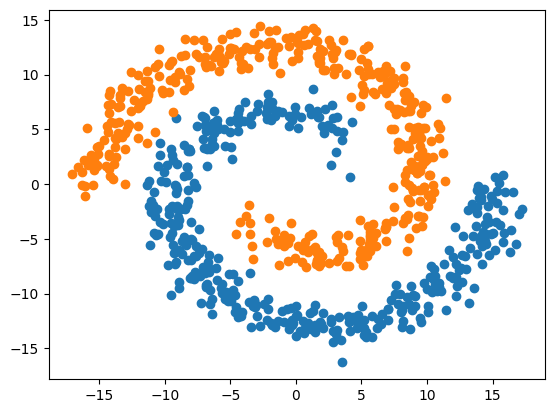

In [16]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt

N = 400
theta = np.sqrt(np.random.rand(N))*2*pi # np.linspace(0,2*pi,100)

r_a = 2*theta + pi
data_a = np.array([np.cos(theta)*r_a, np.sin(theta)*r_a]).T
x_a = data_a + np.random.randn(N,2)

r_b = -2*theta - pi
data_b = np.array([np.cos(theta)*r_b, np.sin(theta)*r_b]).T
x_b = data_b + np.random.randn(N,2)

res_a = np.append(x_a, np.zeros((N,1)), axis=1)
res_b = np.append(x_b, np.ones((N,1)), axis=1)

res = np.append(res_a, res_b, axis=0)
np.random.shuffle(res)

#np.savetxt("result.csv", res, delimiter=",", header="x,y,label", comments="", fmt='%.5f')

plt.scatter(x_a[:,0],x_a[:,1])
plt.scatter(x_b[:,0],x_b[:,1])
plt.show()


In [18]:
res.shape

(800, 3)

In [19]:
X, y = res[:, :2], res[:, 2]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = Sequential([
    Dense(8, activation="tanh", input_shape=(2,)),
    Dense(7, activation="tanh"),
    Dense(6, activation="tanh"),
    Dense(1, activation="sigmoid")
])

# compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history_1500_30 = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=1500,
    batch_size=30
)

Epoch 1/1500


/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4391 - loss: 0.6979 - val_accuracy: 0.6250 - val_loss: 0.6463
Epoch 2/1500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6781 - loss: 0.6399 - val_accuracy: 0.7250 - val_loss: 0.6011
Epoch 3/1500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6969 - loss: 0.6105 - val_accuracy: 0.7188 - val_loss: 0.5825
Epoch 4/1500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7047 - loss: 0.5969 - val_accuracy: 0.7250 - val_loss: 0.5708
Epoch 5/1500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7078 - loss: 0.5882 - val_accuracy: 0.7312 - val_loss: 0.5617
Epoch 6/1500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7094 - loss: 0.5805 - val_accuracy: 0.7250 - val_loss: 0.5552
Epoch 7/1500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7125 - loss: 0.5736 - val_accuracy: 0.7250 - val_loss: 0.5493
Epoch 8/1500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7156 - loss: 0.5675 - val_accuracy: 0.7375 - val_lo

In [20]:
history_1500_1 = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=1500,
    batch_size=1
)

Epoch 1/1500
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - accuracy: 0.9719 - loss: 0.2807 - val_accuracy: 0.9812 - val_loss: 0.0330
Epoch 2/1500
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - accuracy: 0.9875 - loss: 0.0523 - val_accuracy: 0.9937 - val_loss: 0.0198
Epoch 3/1500
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 385us/step - accuracy: 0.9844 - loss: 0.0699 - val_accuracy: 0.9688 - val_loss: 0.0845
Epoch 4/1500
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - accuracy: 0.9828 - loss: 0.0435 - val_accuracy: 0.9750 - val_loss: 0.0601
Epoch 5/1500
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.9922 - loss: 0.0345 - val_accuracy: 0.9937 - val_loss: 0.0162
Epoch 6/1500
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - accuracy: 0.9859 - loss: 0.0646 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 7/1500
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 384us/step - accuracy: 0.9922 - loss: 0.0253 - val_accuracy: 0.9937 - val_loss: 0.0229
Epoch 8/1500
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step - accuracy: 0.9875 -

## (3) The learning rate (Öğrenme oranı)

<u>`circle veri setine`</u> geri dön:

* Gürültü (noise) olmadan,
* Eğitim / test veri oranı %50 olacak şekilde,
* Batch size = 20 kullan.

<u>Sinir ağı</u> ayarları:
* 5 nöronlu tek bir katman,
* Regularization yok,
* `tanh` aktivasyon fonksiyonu.

❓ **Learning rate ile ilgili soru** ❓

Her bir learning rate değeri için (0.0001’den 10’a kadar):
* Algoritmayı 1000 epoch boyunca çalıştır,
* Test loss değerlerini aşağıdaki listeye kaydet,
* Ardından test loss değerlerini learning rate’e göre çiz (plot).

❗️ <u>Uyarı</u> ❗️  
Learning rate’i her değiştirdiğinde sinir ağını mutlaka **yeniden başlat**  
(_play/pause tuşunun solundaki circular arrow_).

LR=0.0001 --> Test Loss=0.7155
LR=0.001 --> Test Loss=0.6892
LR=0.01 --> Test Loss=0.5572
LR=0.1 --> Test Loss=0.0411
LR=1.0 --> Test Loss=0.0055
LR=10.0 --> Test Loss=1.2623


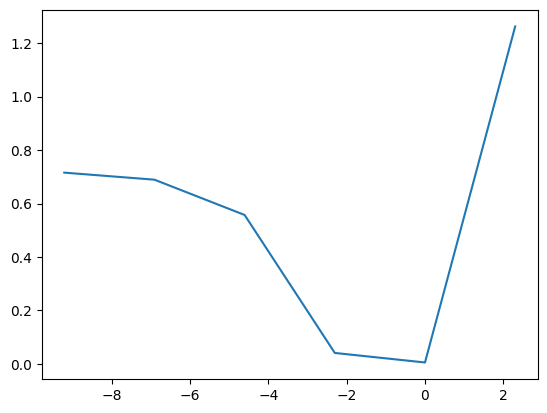

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
# circle dataset
X, y = make_circles(
    n_samples=1000,
    noise=0,
    random_state=42
)
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5, random_state=42)
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
test_loss = []
for lr in learning_rates:
    model = Sequential([
        Dense(5, activation="tanh", input_shape=(2,)),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=SGD(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    history = model.fit(
        X_train,
        y_train,
        epochs=1000,
        batch_size=20,
        verbose=0
    )
    _test_loss, test_acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )
    test_loss.append(_test_loss)
    print(f"LR={lr} --> Test Loss={_test_loss:.4f}")


# test_loss = [BU HÜCREYİ YORUMLAMA VE KAYIP DEĞERLERİNİZİ BU LİSTEDE SAKLAYIN]


plt.plot(np.log(learning_rates), test_loss)

In [24]:
np.log(10)

2.302585092994046

❗️ <u>Uyarı</u> ❗️  
Hem **çok düşük** hem de **çok yüksek** learning rate değerleri yüksek test loss’a yol açar… fakat **farklı nedenlerle**!

* **Düşük learning rate**:
  - Sinir ağının, orta seviyedeki bir learning rate’e benzer şekilde yakınsamasını sağlar
  - Ancak **çok daha yavaş** olur → yani **daha fazla epoch** gerekir

* **Yüksek learning rate**:
  - Algoritmanın tamamen **dağılmasına (diverge)** neden olur
  - Örneğin learning rate \( \alpha = 10 \) ve 400 epoch dene:
    - Loss değerinin sürekli değiştiğini görürsün
    - Bu durum, algoritmanın **farklı yerel minimumlara** yakınsadığını gösterir

🏁 Tebrikler!

💾 Not defterinizi `git add/commit/push` yapmayı unutmayın...